Question 1. There are 5 jurors in a courtroom. Each of them can correctly identify the guilt of the defendant with 70% probability, independent of one another. What is the probability that the jurors will jointly reach the correct verdict if the final decision is by majority vote?

83.70%

# Credit scoring problem setup

Predict whether the customer will repay their credit within 90 days. This is a binary classification problem; we will assign customers into good or bad categories based on our prediction.

In [1]:
import warnings

warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [2]:
from matplotlib import rcParams
rcParams["figure.figsize"] = 11, 8

In [3]:
# Let’s write the function that will replace NaN values with the median for each column.
def fill_nan(table):
    for col in table.columns:
        table[col] = table[col].fillna(table[col].median())
    return table

In [4]:
# data
DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

In [5]:
data = pd.read_csv(DATA_PATH + "credit_scoring_sample.csv", sep=";")
data.head()

,SeriousDlqin2yrs,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,NumberOfTimes90DaysLate,NumberOfTime60-89DaysPastDueNotWorse,MonthlyIncome,NumberOfDependents
0,0,64,0,0.249908,0,0,8158.0,0.0
1,0,58,0,3870.000000,0,0,NaN,0.0
2,0,41,0,0.456127,0,0,6666.0,0.0
3,0,43,0,0.000190,0,0,10500.0,2.0
4,1,49,0,0.271820,0,0,400.0,0.0


In [6]:
data.dtypes

SeriousDlqin2yrs                          int64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
NumberOfTimes90DaysLate                   int64
NumberOfTime60-89DaysPastDueNotWorse      int64
MonthlyIncome                           float64
NumberOfDependents                      float64
dtype: object

In [7]:
data["SeriousDlqin2yrs"].value_counts()

SeriousDlqin2yrs
0    35037
1    10026
Name: count, dtype: int64

In [8]:
data.shape

(45063, 8)

Distribution of the target:


SeriousDlqin2yrs
0    0.777511
1    0.222489
Name: count, dtype: float64

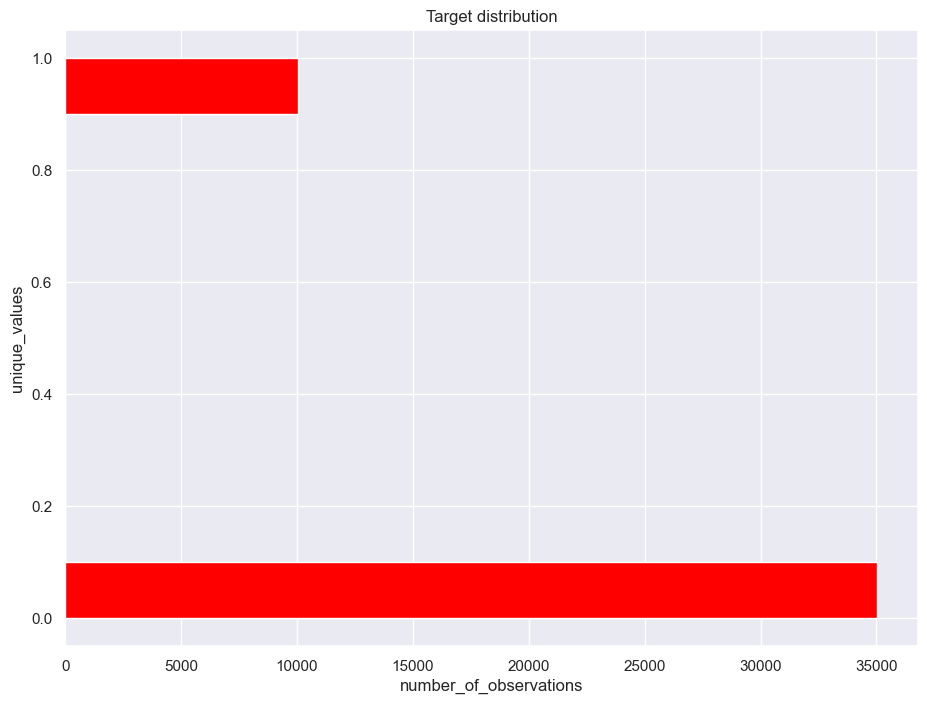

In [9]:
# Check the class balance
ax = data["SeriousDlqin2yrs"].hist(orientation="horizontal", color="red")
ax.set_xlabel("number_of_observations")
ax.set_ylabel("unique_values")
ax.set_title("Target distribution")

print("Distribution of the target:")
data["SeriousDlqin2yrs"].value_counts() / data.shape[0]

In [10]:
# Separate the input variable names by excluding the target:
independent_column_names = [x for x in data if x != "SeriousDlqin2yrs"]
independent_column_names

['age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'NumberOfTimes90DaysLate',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'MonthlyIncome',
 'NumberOfDependents']

In [11]:
# Apply the function to replace NaN values:
table = fill_nan(data)

In [12]:
# Seperate the target variable and input features
X = table[independent_column_names]
y = table["SeriousDlqin2yrs"]

## Bootstrapping

Question 2. Make an interval estimate of the average age for the customers who delayed repayment at the 90% confidence level. Use the example from the article as reference, if needed. Also, use np.random.seed(0) as before. What is the resulting interval estimate?

In [13]:
def get_bootstrap_samples(data, n_samples):
    indices = np.random.randint(0, len(data), (n_samples, len(data)))
    samples = data[indices]
    return samples

def stat_intervals(stat, alpha):
    bounderies = np.percentile(stat, [100 * alpha/2.0, 100 * (1-alpha/2.0)])
    return bounderies

""" not_delayed_customers = data.loc[
    data["SeriousDlqin2yrs"] == 0, "age"
].values """

delayed_customers = data.loc[
    data["SeriousDlqin2yrs"] == 1, "age"
].values

np.random.seed(0)

""" not_delayed_customers_mean = [
    np.mean(sample) for sample in get_bootstrap_samples(not_delayed_customers, 1000)
] """
delayed_customers_mean = [
    np.mean(sample) for sample in get_bootstrap_samples(delayed_customers, 1000)
]

print(
    "delayed customers: mean interval", stat_intervals(delayed_customers_mean, 0.1)
)
""" print(
    "not delayed customers: mean interval", stat_intervals(not_delayed_customers_mean, 0.1)
) """
print("answer: ",  stat_intervals(delayed_customers_mean, 0.1))

delayed customers: mean interval [45.71379414 46.12700479]
answer:  [45.71379414 46.12700479]


### official answer

In [14]:
def get_bootstrap_samples(data, n_samples):
    """Generate samples using bootstrapping."""
    indices = np.random.randint(0, len(data), (n_samples, len(data)))
    samples = data[indices]
    return samples


def stat_intervals(stat, alpha):
    """Make an interval estimate."""
    boundaries = np.percentile(stat, [100 * alpha / 2.0, 100 * (1 - alpha / 2.0)])
    return boundaries


# Save the ages of those who let a delay
churn = data[data["SeriousDlqin2yrs"] == 1]["age"].values

# Set the random seed for reproducibility
np.random.seed(0)

# Generate bootstrap samples and calculate the mean for each sample
churn_mean_scores = [np.mean(sample) for sample in get_bootstrap_samples(churn, 1000)]

# Print the interval estimate for the sample means
print("Mean interval", stat_intervals(churn_mean_scores, 0.1))

Mean interval [45.71379414 46.12700479]


# Logistic regression

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [16]:
# Now, we will create a LogisticRegression model and use class_weight='balanced' 
# to make up for our unbalanced classes.

lr = LogisticRegression(random_state=5, class_weight="balanced")

In [17]:
# find the best regularization coeff
parameters = {"C": (0.0001, 0.001, 0.01, 0.1, 1, 10)}

# In order to find optimal value of C, apply stratified 5-fold validation and look at ROC AUC against 
# different values of parameter C
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)

## One of the important metrics of model quality is the Area Under the Curve (AUC). ROC AUC varies from 0 to 1. The closer ROC AUC is to 1, the better the quality of the classification model.

Question 3. Perform a Grid Search with the scoring metric “roc_auc” for the parameter C. Which value of the parameter C is optimal?

In [18]:
# data not scaled because the course material didint scaled the data
grid_search = GridSearchCV(lr,param_grid=parameters, scoring="roc_auc", cv=skf)
grid_search = grid_search.fit(X,y)

grid_search.best_estimator_

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",10
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",5
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`m

Question 4. Can we consider the best model stable? The model is stable if the standard deviation on validation is less than 0.5%. Save the ROC AUC value of the best model; it will be useful for the following tasks.



## What does "stable model" mean?

When we perform **k-fold cross-validation**, the model is trained and evaluated multiple times.

For example, suppose we use **5-fold cross-validation**.

Instead of getting one ROC AUC score, we get something like:

| Fold | ROC AUC |
| ---- | ------- |
| 1    | 0.790   |
| 2    | 0.785   |
| 3    | 0.792   |
| 4    | 0.788   |
| 5    | 0.784   |

Now we can compute

* Mean ROC AUC
* Standard deviation (how much the scores vary)

---

## Why is standard deviation important?

Imagine two models.

### Model A

| Fold | ROC AUC |
| ---- | ------- |
| 1    | 0.79    |
| 2    | 0.78    |
| 3    | 0.79    |
| 4    | 0.79    |
| 5    | 0.78    |

Mean = **0.786**

Standard deviation = **0.004**

The performance is almost identical on every fold.

This is called a **stable model**.

---

### Model B

| Fold | ROC AUC |
| ---- | ------- |
| 1    | 0.65    |
| 2    | 0.90    |
| 3    | 0.74    |
| 4    | 0.85    |
| 5    | 0.79    |

Mean = **0.786**

Standard deviation = **0.10**

The average is exactly the same!

But some folds perform terribly while others perform amazingly.

This model is **unstable**.

---

## What does GridSearchCV store?

After GridSearchCV finishes, it stores lots of information.

```
grid_search.cv_results_
```

This is basically a dictionary.

Some useful keys are

```
mean_test_score
std_test_score
params
rank_test_score
```

For example

```
grid_search.cv_results_
```

might look like

| params  | mean_test_score | std_test_score |
| ------- | --------------- | -------------- |
| Model 1 | 0.781           | 0.006          |
| Model 2 | 0.788           | 0.003          |
| Model 3 | 0.785           | 0.009          |

---

## What does this line mean?

```python
grid_search.cv_results_["std_test_score"][1]
```

Let's separate it.

First,

```python
grid_search.cv_results_["std_test_score"]
```

returns something like

```python
array([
    0.0062,
    0.00356,
    0.0081
])
```

Each number corresponds to one parameter combination.

Then

```python
[1]
```

means

> Give me the second model's standard deviation.

Result

```python
0.003560178281786074
```

---

## Is 0.00356 equal to 0.356%?

Yes.

Remember

ROC AUC ranges from **0 to 1**, not 0 to 100.

```
0.00356
```

means

```
0.356%
```

because

```
0.00356 × 100 = 0.356%
```

The question says

> Stable if standard deviation is less than 0.5%.

Since

```
0.356% < 0.5%
```

the answer is

> **Yes**

---

## What does this line mean?

```python
grid_search.best_score_
```

This returns

```
0.7879690936143
```

This is **not** the score from a single fold.

It is the **mean ROC AUC across all cross-validation folds** for the best parameter combination.

For example

Suppose the best model got

| Fold | ROC AUC |
| ---- | ------- |
| 1    | 0.789   |
| 2    | 0.787   |
| 3    | 0.791   |
| 4    | 0.786   |
| 5    | 0.787   |

Average

```
(0.789 + 0.787 + 0.791 + 0.786 + 0.787)/5

= 0.7879
```

This becomes

```python
grid_search.best_score_
```

---

## Why did they use index `[1]` instead of `best_index_`?

In the solution, they wrote:

```python
grid_search.cv_results_["std_test_score"][1]
```

This assumes that the **best model happened to be the second parameter combination** (index `1`).

A more general and safer approach is:

```python
best_idx = grid_search.best_index_

grid_search.cv_results_["std_test_score"][best_idx]
```

This works regardless of which parameter combination is best.

---

## Summary

* **`best_score_`** → Mean ROC AUC of the best parameter combination across all CV folds.
* **`std_test_score`** → Standard deviation of that ROC AUC across folds.
* A **small standard deviation** means the model performs consistently across different train/validation splits, so it's considered **stable**.
* Here:

  * Mean ROC AUC = **0.78797**
  * Standard deviation = **0.00356** (or **0.356%**)
  * Since **0.356% < 0.5%**, the model is considered **stable**.


In [19]:
grid_search.cv_results_["std_test_score"][1]
# best_idx = grid_search.best_index_
#grid_search.cv_results_["std_test_score"][best_idx]


np.float64(0.006798767961125002)

In [21]:
""" 

0.00679 * 100 = 0.679 > 0.5 , so the model is not stable

 """

' \n\n0.00679 * 100 = 0.679 > 0.5 , so the model is not stable\n\n '

In [20]:
# The ROC AUC value of the best model:
grid_search.best_score_

np.float64(0.7953263283670138)

## Feature importance

Question 5. Feature importance is defined by the absolute value of its corresponding coefficient. First, you need to normalize all of the feature values so that it will be valid to compare them. What is the most important feature for the best logistic regression model?

## Does weight determines importance of features

The short answer is:

> **Yes, but only under certain conditions.**

Many beginners hear:

> **"Larger weight = more important feature."**

This is **sometimes true**, but **not always**. Let's understand why.

---

# Recall the logistic regression equation

The model computes

[
z = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b
]

Then converts it to a probability

[
P(y=1|x)=\sigma(z)
]

where

[
\sigma(z)=\frac{1}{1+e^{-z}}
]

Each weight tells us **how much that feature contributes to the log-odds**, not directly to the probability.

---

# Example 1: Features on the same scale

Suppose

| Feature    | Weight |
| ---------- | -----: |
| Age        |    2.5 |
| Income     |    0.8 |
| Experience |   -1.7 |

If all features are standardized (mean = 0, std = 1), then yes:

* Age has the strongest positive influence.
* Experience has a strong negative influence.
* Income has a weaker positive influence.

So

```
|2.5| > |1.7| > |0.8|
```

means

```
Age > Experience > Income
```

in terms of importance.

---

# Example 2: Different feature scales

Now suppose

Age

```
20–60
```

Income

```
10,000–2,000,000
```

Weights become

| Feature |  Weight |
| ------- | ------: |
| Age     |       2 |
| Income  | 0.00001 |

You might think

> Age is much more important.

Not necessarily.

Imagine someone earns

```
₹1,000,000
```

Contribution:

```
0.00001 × 1,000,000 = 10
```

Age:

```
2 × 40 = 80
```

Both contribute significantly, despite the tiny income weight.

The small weight compensates for the large numerical scale of the feature.

So **raw weights cannot be compared across features with different units or scales**.

---

# This is why we standardize features

If every feature is standardized:

[
x'=\frac{x-\mu}{\sigma}
]

then every feature has roughly the same scale.

Now the weights become directly comparable.

For example

| Feature      | Weight |
| ------------ | -----: |
| Age          |    1.8 |
| Income       |    0.3 |
| Credit Score |   -2.2 |

Now you can say

* Credit Score is most influential.
* Age is second.
* Income is least influential.

---

# What does the sign tell us?

Positive weight

```
+
```

means

As the feature increases,

```
Probability of class 1 increases.
```

Negative weight

```
-
```

means

As the feature increases,

```
Probability of class 1 decreases.
```

Example:

Predicting whether someone buys a product.

| Feature | Weight |
| ------- | -----: |
| Salary  |   +1.4 |
| Age     |   -0.7 |

Interpretation

Higher salary

➡ More likely to buy.

Higher age

➡ Less likely to buy.

---

# What does the magnitude tell us?

The magnitude

```
|w|
```

tells us how strongly the feature changes the **log-odds**.

Example

| Feature | Weight |
| ------- | -----: |
| x₁      |      5 |
| x₂      |    0.2 |

If both features increase by one standardized unit,

* (x_1) changes the log-odds much more than (x_2).

---

# But remember an important caveat: correlated features

Suppose

```
Height (cm)
```

and

```
Height (feet)
```

Both contain essentially the same information.

Logistic regression might assign

```
Height(cm) = 2.3
Height(feet) = 0.1
```

or

```
Height(cm) = 1.2
Height(feet) = 1.1
```

or even

```
Height(cm) = -0.5
Height(feet) = 3.8
```

depending on the data and regularization.

This happens because correlated features "share" the predictive information, so individual coefficients become unstable.

---

# Rule of thumb

You can interpret coefficients as feature importance **only if**:

* ✅ Features are standardized.
* ✅ Features are not highly correlated (low multicollinearity).
* ✅ You're comparing the absolute values of the coefficients.

Otherwise, coefficient size alone can be misleading.

---

## Summary

| Statement                                                            | True?                                    |
| -------------------------------------------------------------------- | ---------------------------------------- |
| Larger absolute weight generally means a more influential feature    | ✅ Yes, if features are on the same scale |
| Positive weight increases the probability of class 1                 | ✅ Yes                                    |
| Negative weight decreases the probability of class 1                 | ✅ Yes                                    |
| Raw weights from unscaled features indicate feature importance       | ❌ No                                     |
| Standardizing features makes coefficient comparisons more meaningful | ✅ Yes                                    |

As you continue studying machine learning, you'll also encounter **feature importance** measures for trees (Random Forest, XGBoost), which are computed very differently from logistic regression coefficients. They're a useful contrast once you're comfortable with linear models.


In [21]:
from sklearn.preprocessing import StandardScaler

lr = LogisticRegression(random_state=5, C=0.001, class_weight="balanced", max_iter=5000)
scale = StandardScaler()

lr.fit(scale.fit_transform(X), y)

pd.DataFrame({
    "feat" : independent_column_names, "coef" : lr.coef_.flatten().tolist()
}).sort_values(by="coef", ascending=False)

,feat,coef
1,NumberOfTime30-59DaysPastDueNotWorse,0.723421
3,NumberOfTimes90DaysLate,0.516656
4,NumberOfTime60-89DaysPastDueNotWorse,0.195486
6,NumberOfDependents,0.101722
2,DebtRatio,-0.024068
5,MonthlyIncome,-0.163015
0,age,-0.417115


Question 6. Calculate how much DebtRatio affects our prediction using the softmax function. What is its value?

## what is a softmax function

Since you're learning logistic regression and are about to move into multiclass classification, **softmax** is the natural next step. Think of it as a generalization of the sigmoid function.

---

# First, let's recall sigmoid

For **binary classification**, logistic regression computes

$$
z = w^Tx + b
$$

Then applies the sigmoid function:

$$
P(y=1)=\frac{1}{1+e^{-z}}
$$

The sigmoid converts **one number** into **one probability**.

Example:

```
z = 2.3

Sigmoid(z) = 0.909
```

Meaning

```
P(Class 1) = 90.9%
P(Class 0) = 9.1%
```

Only **two classes** exist, so one probability determines the other.

---

# What if there are 3 classes?

Suppose we want to classify an animal as

```
Cat
Dog
Horse
```

Now sigmoid isn't enough because we need **three probabilities**, not one.

The model first computes a score (called a **logit**) for each class.

Example:

```
Cat   : 2.5
Dog   : 1.2
Horse : 0.3
```

These are **not probabilities**.

Notice

```
2.5 + 1.2 + 0.3 = 4
```

They don't sum to 1.

They can even be negative.

---

# Softmax converts scores into probabilities

Softmax takes all the scores together and converts them into probabilities.

The formula is

$$
P(y=i)=\frac{e^{z_i}}{\sum_{j=1}^{K}e^{z_j}}
$$

where

* (z_i) = score for class (i)
* (K) = number of classes

---

Let's use the previous example.

Scores

```
Cat    = 2.5
Dog    = 1.2
Horse  = 0.3
```

Exponentiate them.

```
e^2.5 ≈ 12.18
e^1.2 ≈ 3.32
e^0.3 ≈ 1.35
```

Now add them.

```
12.18 + 3.32 + 1.35
= 16.85
```

Now divide each one.

Cat

```
12.18 / 16.85 = 0.723
```

Dog

```
3.32 / 16.85 = 0.197
```

Horse

```
1.35 / 16.85 = 0.080
```

Final probabilities

| Class | Probability |
| ----- | ----------: |
| Cat   |       72.3% |
| Dog   |       19.7% |
| Horse |        8.0% |

Notice

```
72.3 + 19.7 + 8.0 = 100%
```

Perfect!

---

# Why do we use (e^x)?

You might wonder:

> Why not just divide the scores directly?

Suppose the scores are

```
2
1
0
```

Direct division gives

```
2/3
1/3
0
```

This isn't ideal because:

* Negative scores would cause problems.
* A score of 0 always gets 0 probability.
* Small score differences aren't emphasized.

Using exponentials:

```
e² = 7.39
e¹ = 2.72
e⁰ = 1
```

Now

```
7.39
2.72
1
```

The larger scores become much more dominant.

Exponentials also ensure every value is **positive**, making valid probabilities possible.

---

# Intuition

Imagine three students taking an exam.

Raw scores:

```
Alice = 95
Bob   = 70
Chris = 60
```

Softmax answers the question:

> "Based on these scores, what is the probability that each student is the top performer?"

It doesn't just normalize the scores—it **amplifies** the highest score while still assigning some probability to the others.

---

# Softmax in Logistic Regression

For multiclass logistic regression, the model computes one linear equation **per class**.

Suppose we have 3 classes.

```
Cat

z₁ = w₁x + b₁
```

```
Dog

z₂ = w₂x + b₂
```

```
Horse

z₃ = w₃x + b₃
```

These produce three scores:

```
2.5
1.2
0.3
```

Softmax converts them into

```
0.723
0.197
0.080
```

The predicted class is simply the one with the highest probability:

```
argmax(probabilities)
```

which is **Cat**.

---

# Sigmoid vs Softmax

| Sigmoid                                                 | Softmax                               |
| ------------------------------------------------------- | ------------------------------------- |
| Binary classification                                   | Multiclass classification             |
| One output neuron                                       | One output neuron per class           |
| Outputs one probability                                 | Outputs a probability for every class |
| Probabilities sum to 1 only because there are 2 classes | Probabilities always sum to 1         |
| Independent output                                      | All outputs compete with each other   |

---

# Visual intuition

Suppose the model outputs these raw scores:

```
Cat    : 10
Dog    : 9
Horse  : 1
```

Softmax gives roughly:

```
Cat    : 73%
Dog    : 27%
Horse  : 0%
```

Now increase Cat's score:

```
Cat    : 20
Dog    : 9
Horse  : 1
```

Softmax becomes approximately:

```
Cat    : 99.99%
Dog    : 0.01%
Horse  : ~0%
```

Notice how increasing one score **reduces the probabilities of the other classes**. This is because all classes compete for a total probability of 1.

---

### Connection to what you've already learned

You've learned that:

* **Binary Logistic Regression** uses **Sigmoid + Binary Cross-Entropy Loss**.
* **Multiclass Logistic Regression** uses **Softmax + Categorical Cross-Entropy Loss**.

These two combinations are direct counterparts. Once you understand sigmoid for two classes, softmax is essentially the same idea extended to any number of classes.


In [24]:
print((np.exp(lr.coef_[0]) / np.sum(np.exp(lr.coef_[0])))[2])

0.11423641577786514


Question 7. Let’s see how we can interpret the impact of our features. For this, recalculate the logistic regression with absolute values, that is without scaling. Next, modify the customer’s age by adding 20 years, keeping the other features unchanged. How many times will the chance that the customer will not repay their debt increase? You can find an example of the theoretical calculation here.

In [22]:
lr = LogisticRegression(C=0.001, random_state=5, class_weight="balanced", max_iter=500)
lr.fit(X,y)
pd.DataFrame(
    {"feat" : independent_column_names, "coeff" : lr.coef_.flatten().tolist()}
).sort_values("coeff", ascending=False)

,feat,coeff
1,NumberOfTime30-59DaysPastDueNotWorse,0.468350
3,NumberOfTimes90DaysLate,0.403958
6,NumberOfDependents,0.072013
4,NumberOfTime60-89DaysPastDueNotWorse,0.051182
2,DebtRatio,-0.000017
5,MonthlyIncome,-0.000018
0,age,-0.029959


In [23]:
np.exp(lr.coef_[0][0] * 20)

np.float64(0.5492574946022907)

It is $$ \exp^{\beta\delta} $$ times more likely that the customer won’t repay the debt, where 
 is the feature value increment. That means that if we increased the age by 20 years, the odds that the customer won’t repay would increase by 0.69 times.

## Random Forest

In [24]:
# Import random forest classifier
from sklearn.ensemble import RandomForestClassifier

In [25]:
# Initilize random forest with 100 trees and balance target classes

rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42, class_weight="balanced")

In [26]:
# Search best params among the following values

parameters = {
    "max_features" : [1,2,4],
    "min_samples_leaf" : [3,7,5,9],
    "max_depth" : [5,10,15]
}

Question 8. How much higher is the ROC AUC of the best random forest model than that of the best logistic regression on validation? Select the closest answer.

In [27]:
rf_grid_search = GridSearchCV(
    rf, parameters, n_jobs=-1, cv=skf, verbose=True, scoring="roc_auc"
)

rf_grid_search = rf_grid_search.fit(X,y)
print(rf_grid_search.best_score_ - grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
0.040452216736239444


Question 9. What feature has the weakest impact in Random Forest model?

In [28]:
independent_column_names[
    np.argmin(rf_grid_search.best_estimator_.feature_importances_)
]

'NumberOfDependents'

In [29]:
# Rating feature importance

pd.DataFrame(
    {
        "feat": independent_column_names,
        "coef": rf_grid_search.best_estimator_.feature_importances_,
    }
).sort_values(by="coef", ascending=False)

,feat,coef
1,NumberOfTime30-59DaysPastDueNotWorse,0.300290
3,NumberOfTimes90DaysLate,0.278749
4,NumberOfTime60-89DaysPastDueNotWorse,0.156534
0,age,0.115860
2,DebtRatio,0.076082
5,MonthlyIncome,0.057994
6,NumberOfDependents,0.014491


Question 10. What is the most significant advantage of using Logistic Regression versus Random Forest for this problem?

Spent less time for model fitting;

Fewer variables to iterate;

Feature interpretability;

Linear properties of the algorithm.

ans : Feature interpretability;

On the one hand, the Random Forest model works better for our credit scoring problem. Its performance is 4% higher. The reason for such a result is a small number of features and the compositional property of random forests.

On the other hand, the main advantage of Logistic Regression is that we can interpret the feature impact on the model outcome.

## Bagging

In [30]:
# Import modules and set up the parameters for bagging:

from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_score

In [36]:
parameters = {
    "max_features": [2, 3, 4],
    "max_samples": [0.5, 0.7, 0.9],
    "estimator__C": [0.0001, 0.001, 0.01, 1, 10, 100],
}

Question 11. Fit a bagging classifier with random_state=42. For the base classifiers, use 100 logistic regressors and use RandomizedSearchCV instead of GridSearchCV. It will take a lot of time to iterate over all 54 variants, so set the maximum number of iterations for RandomizedSearchCV to 20. Don’t forget to set the parameters cv and random_state=1. What is the best ROC AUC you achieve?

In [37]:
bg = BaggingClassifier(
    LogisticRegression(class_weight="balanced"),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rgrid_search = RandomizedSearchCV(
    bg,
    parameters,
    n_jobs=-1,
    scoring="roc_auc",
    cv=skf,
    n_iter=20,
    random_state=1,
    verbose=True
)

rgrid_search = rgrid_search.fit(X, y)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [38]:
rgrid_search.best_score_

np.float64(0.8058615128067338)

Question 12. Give an interpretation of the best parameters for bagging. Why are these values of max_features and max_samples the best?

For bagging it’s important to use as few features as possible;

Bagging works better on small samples;

Less correlation between single models;

The higher the number of features, the lower the loss of information.

ans : Less correlation between single models;

The advantage of Random Forest is that the trees in the composition are not highly correlated. Similarly, for bagging with logistic regression, the weaker the correlation between single models, the higher the accuracy. Since in logistic regression there is almost no randomness, we have to change the set of features to minimize the correlation between our single models.